# Project 1: Acrobot Swing-up and Balance Control

## 基于能量成型（Energy Shaping）与 LQR 切换控制的双摆系统课程设计

**项目名称**: Acrobot Swing-up and Balance Control via Energy Shaping and LQR

---

## 1. 项目概述

### 1.1 目标
实现 Acrobot（双摆系统）从底部悬垂状态（downward equilibrium）到顶部平衡状态（upward equilibrium）的全自主控制。

### 1.2 系统描述

Acrobot 是一个二连杆、二自由度的平面机器人：
- **连杆1**（Shoulder）：长度 $l_1$，质量 $m_1$，质心距关节 $l_{c1}$
- **连杆2**（Elbow）：长度 $l_2$，质量 $m_2$，质心距关节 $l_{c2}$
- **关节1**（Shoulder）：**被动关节**（无驱动）
- **关节2**（Elbow）：**主动关节**（有驱动，控制力矩为 $u$）

状态变量：$x = [\theta_1, \theta_2, \dot{\theta}_1, \dot{\theta}_2]^T$

目标状态：两连杆均竖直向上，即 $\theta_1 = \pi, \theta_2 = 0$，角速度均为 0

---

## 2. 动力学建模

Acrobot 的动力学方程可写为标准操作手形式（Manipulator Equation）：

$$M(q)\ddot{q} + C(q, \dot{q})\dot{q} + G(q) = Bu$$

其中 $q = [\theta_1, \theta_2]^T$，$u$ 为施加在肘关节的力矩。

### 2.1 质量矩阵 $M(q)$

$$M(q) = \begin{bmatrix} M_{11} & M_{12} \\ M_{21} & M_{22} \end{bmatrix}$$

- $M_{11} = I_1 + I_2 + m_2 l_1^2 + 2m_2 l_1 l_{c2} \cos(\theta_2)$
- $M_{12} = M_{21} = I_2 + m_2 l_1 l_{c2} \cos(\theta_2)$
- $M_{22} = I_2$

### 2.2 科氏力/离心力矩阵 $C(q, \dot{q})$

$$C(q, \dot{q}) = \begin{bmatrix} -m_2 l_1 l_{c2} \sin(\theta_2) \dot{\theta}_2 & -m_2 l_1 l_{c2} \sin(\theta_2) (\dot{\theta}_1 + \dot{\theta}_2) \\ m_2 l_1 l_{c2} \sin(\theta_2) \dot{\theta}_1 & 0 \end{bmatrix}$$

### 2.3 重力项 $G(q)$

$$G(q) = \begin{bmatrix} -(m_1 l_{c1} + m_2 l_1)g \sin(\theta_1) - m_2 l_{c2} g \sin(\theta_1 + \theta_2) \\ -m_2 l_{c2} g \sin(\theta_1 + \theta_2) \end{bmatrix}$$

### 2.4 输入矩阵 $B$

$$B = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

> 第一个元素为 0 表示肩关节无驱动，体现系统的**欠驱动**特性。

### 2.5 系统总能量

$$E(x) = \frac{1}{2}\dot{q}^T M(q) \dot{q} + U(q)$$

势能：$U(q) = -(m_1 l_{c1} + m_2 l_1)g \cos(\theta_1) - m_2 l_{c2} g \cos(\theta_1 + \theta_2)$

目标能量（顶部平衡点）：$E_{des} = (m_1 l_{c1} + m_2 l_1)g + m_2 l_{c2} g$


In [1]:
# 导入必要的库和模块
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# 添加 src 目录到路径
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from acrobot import Acrobot
from controllers import EnergyShapingController, LQRController, HybridController
from utils import linearize_system, evaluate_performance
from simulate import simulate_acrobot_swing_up, plot_simulation_results
from visualize import animate_acrobot, plot_snapshots, plot_energy_breakdown

# 设置绘图参数
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("环境初始化完成！")

环境初始化完成！


## 3. 控制器设计

### 3.1 能量成型控制（Energy Shaping）

能量成型控制的核心思想：通过控制输入调节系统总能量，使其趋近于目标能量 $E_{des}$。

**Spong (1994) 控制律**：
$$\bar{u} = -k_E \cdot \dot{\theta}_2 \cdot (E - E_{des})$$

**改进控制律（结合 Collocated PFL）**：
$$v = \ddot{\theta}_2^{des} = -k_p \theta_2 - k_d \dot{\theta}_2 - k_E \dot{\theta}_2 (E - E_{des})$$

再通过 PFL 转换为实际力矩 $u$。

### 3.2 LQR 稳定控制

在目标平衡点 $x^* = [\pi, 0, 0, 0]^T$ 附近线性化，得到：
$$\dot{\bar{x}} = A \bar{x} + B_{lin} u$$

求解代数 Riccati 方程：
$$A^T P + PA - PB R^{-1} B^T P + Q = 0$$

LQR 增益：$K = R^{-1} B^T P$，控制律：$u = -K(x - x^*)$

### 3.3 切换逻辑

基于 LQR Cost-to-Go 的切换准则，结合状态约束和滞后机制：
$$J(x) = (x - x^*)^T P (x - x^*) < \epsilon$$

同时要求切换时速度和角度在允许范围内（$|\dot{\theta}_1| < 3.0$, $|\dot{\theta}_2| < 5.0$, $|\theta_2| < \pi$），确保 LQR 在其有效吸引域内接管控制。

Acrobot Swing-up and Balance 仿真
初始状态: [0.   0.   0.05 0.  ]
目标状态: [3.14159265 0.         0.         0.        ]
初始能量: -19.6167 J
目标能量: 19.6200 J

--- LQR 设计 ---
LQR 闭环特征值: [-7.75547269+2.92812805j -7.75547269-2.92812805j -0.06270363+2.6856777j
 -0.06270363-2.6856777j ]
LQR 增益 K: [-2.41222794  0.63329236  0.87419045  1.41333523]

--- Energy Shaping 控制器 ---

--- 混合控制器 ---
[t=1.845s] Switched to LQR (cost=15.4969, q2=-0.899, dq1=-2.213, dq2=4.922)

--- 性能评估 ---
settling_time: N/A
overshoot: 35.7905
max_torque: 10.0000
avg_torque: 1.9692
steady_error: 0.4314
energy_consumption: 162.3159

切换次数: 1
  t=1.845s: SWING_UP -> LQR (cost=15.4969)

结果图已保存至: e:\HITSZ\Underactuated_Robotics_Course_Design\acrobot_project\figures\swing_up_results.png


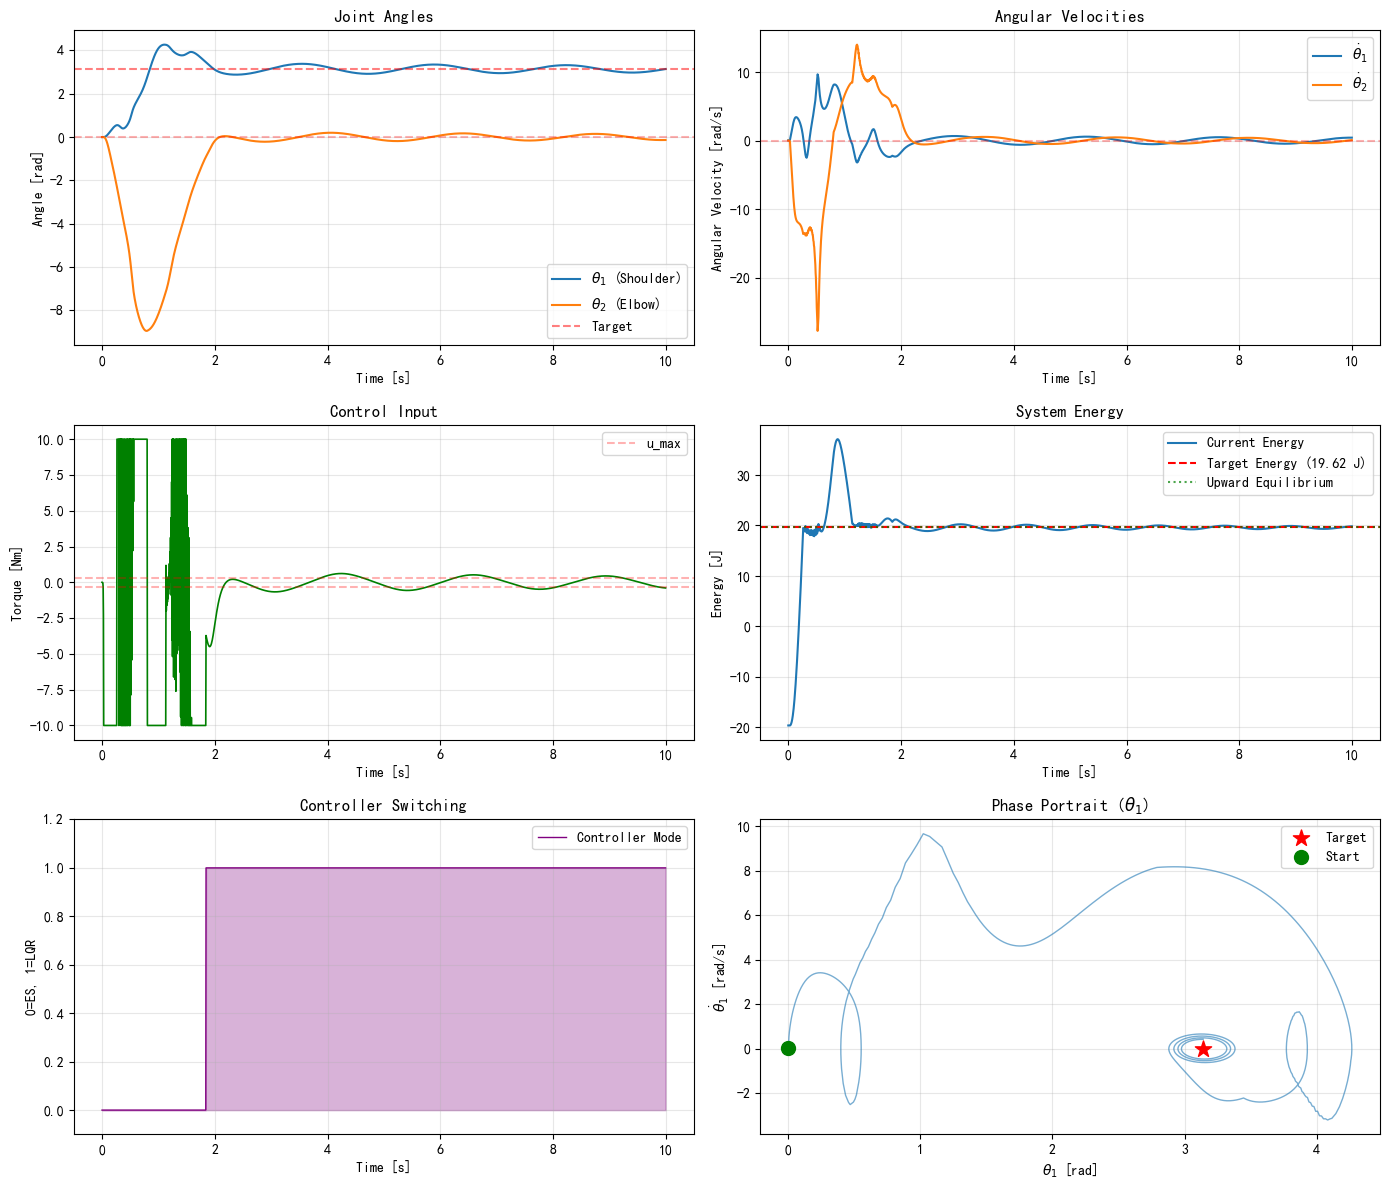

In [2]:
# 运行主仿真
results = simulate_acrobot_swing_up(
    t_final=10.0,
    dt=0.005,
    k_e=30.0,
    k_p=50.0,
    k_d=10.0,
    Q=np.diag([10, 10, 1, 1]),
    R=np.array([[1.0]]),
    switching_threshold=20.0,
    u_max=10.0,
    save_results=True
)

---

## 4. 仿真结果

### 4.1 状态轨迹与控制输入

下图展示了 Acrobot 从初始下垂状态到顶部平衡状态的完整控制过程：

- 左侧上图：关节角度 $\theta_1, \theta_2$
- 右侧上图：关节角速度 $\dot{\theta}_1, \dot{\theta}_2$
- 左侧中图：控制输入力矩 $u$
- 右侧中图：系统总能量变化
- 左侧下图：控制器切换时间线
- 右侧下图：$\theta_1$ 相图

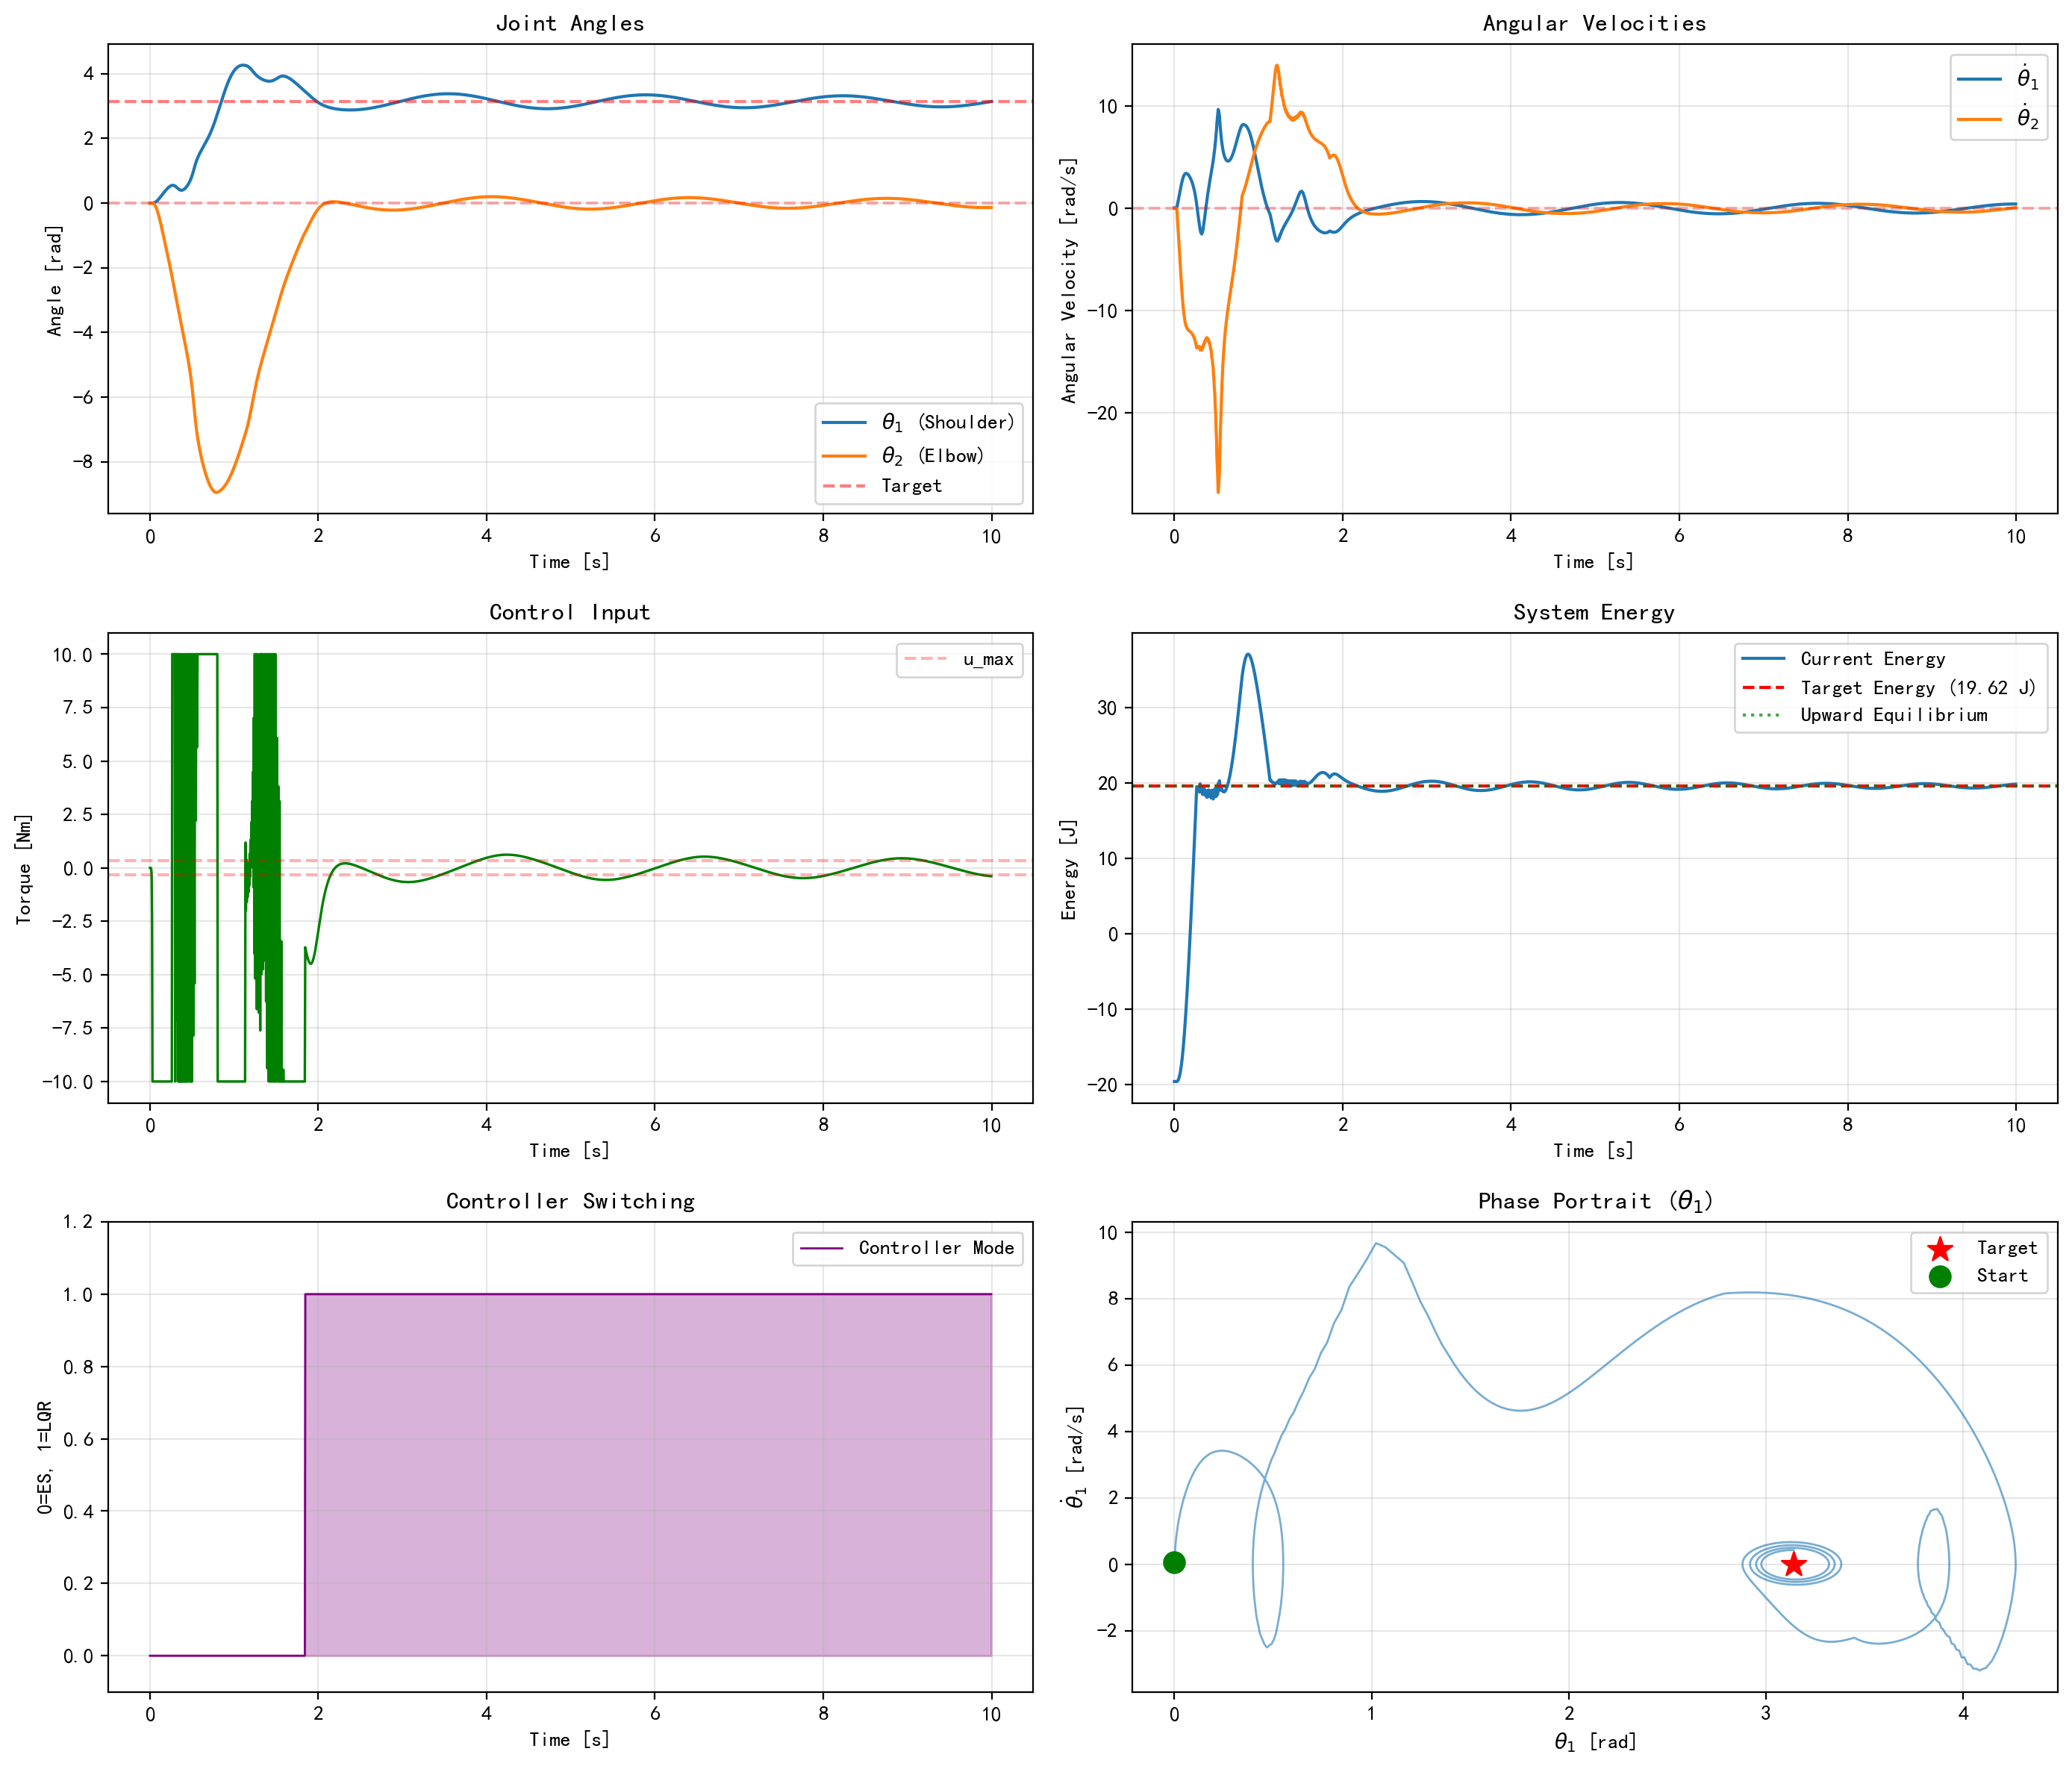

In [3]:
# 显示仿真结果图
from IPython.display import Image, display
display(Image(filename='figures/swing_up_results.png'))

### 4.2 能量分析

能量成型控制器通过逐步增加系统总能量，使其趋近于顶部平衡点的势能。当系统能量接近目标值且状态进入 LQR 吸引域时，控制器平滑切换至 LQR 进行精细稳定。

能量分解图已保存至 figures/energy_breakdown.png


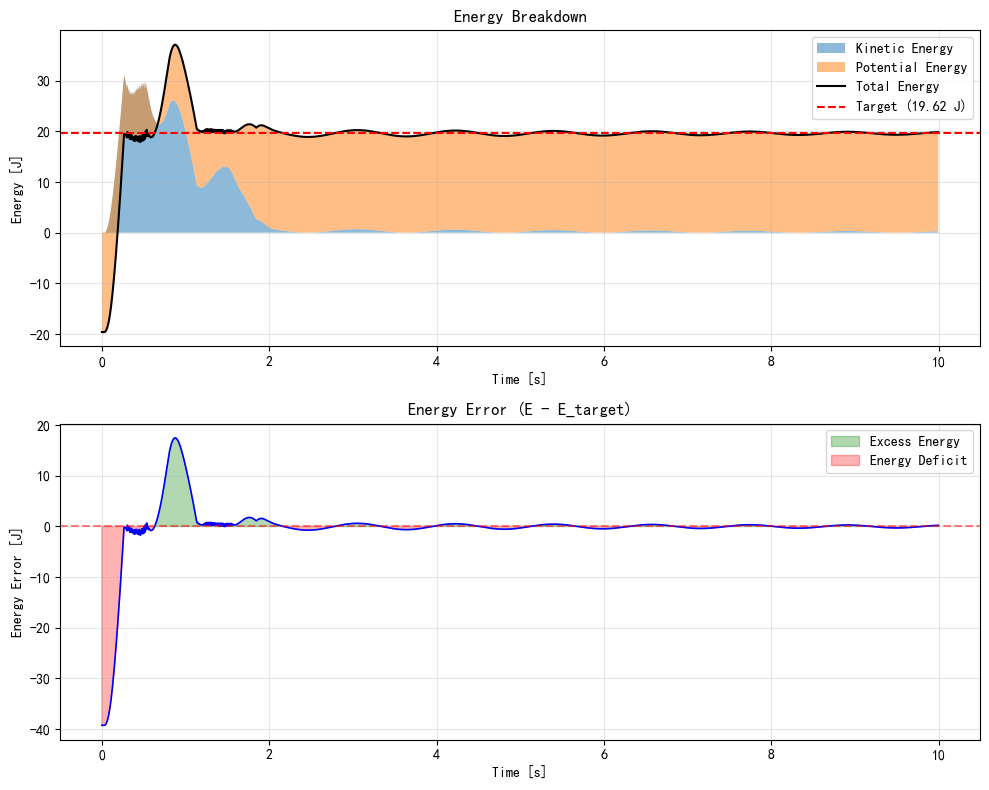

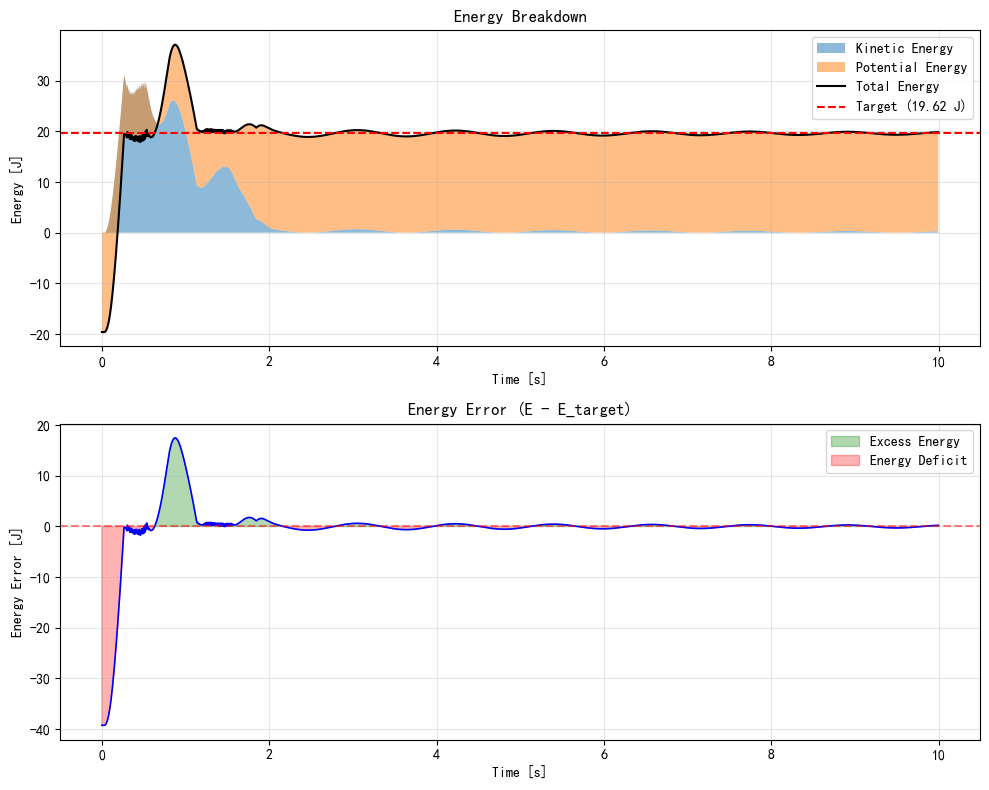

In [4]:
# 生成并显示能量分解图
plot_energy_breakdown(
    results['t'],
    results['x'],
    results['plant'],
    filename='figures/energy_breakdown.png',
    show=True
)

### 4.3 运动快照

以下展示了 Acrobot 在不同时间点的姿态快照：

快照图已保存至 figures/snapshots.png


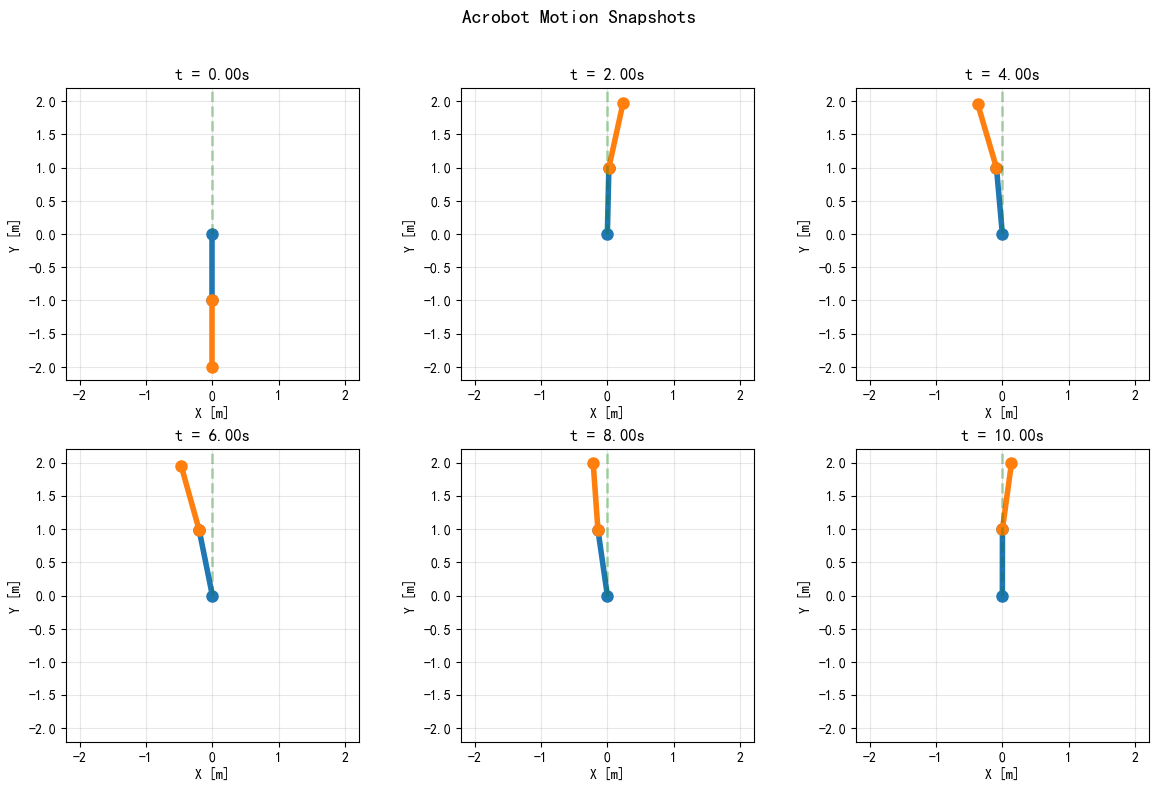

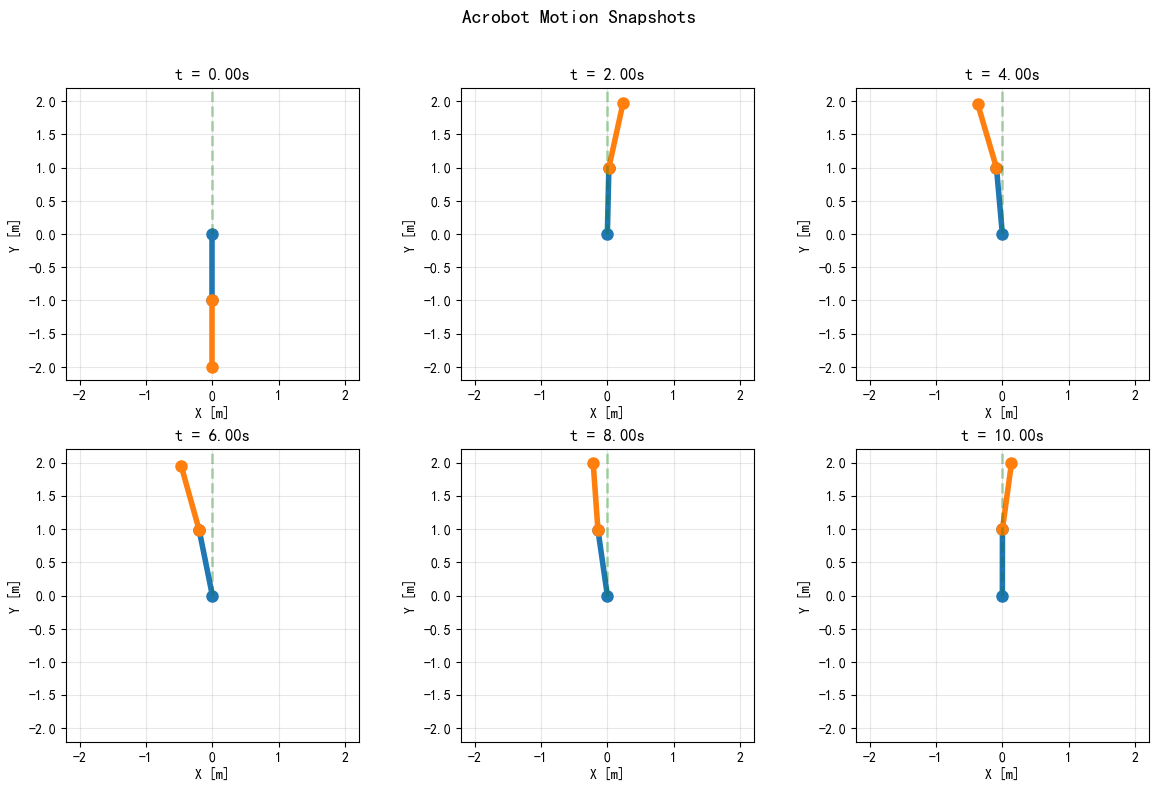

In [5]:
# 生成并显示运动快照
plot_snapshots(
    results['t'],
    results['x'],
    results['plant'],
    filename='figures/snapshots.png',
    n_snapshots=6,
    show=True
)

### 4.4 动画演示

生成 Acrobot 摆动的 GIF 动画（保存至 `animations/acrobot_swing_up.gif`）：

动画已保存至 animations/acrobot_swing_up.gif


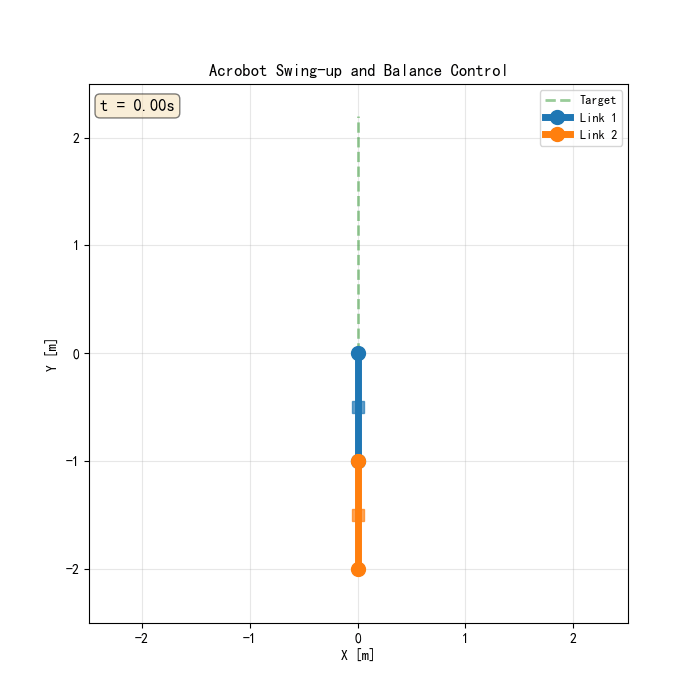

In [6]:
# 生成动画
animate_acrobot(
    results['t'],
    results['x'],
    results['plant'],
    filename='animations/acrobot_swing_up.gif',
    fps=30,
    show=False
)

from IPython.display import Image, display
display(Image(filename='animations/acrobot_swing_up.gif'))

---

## 5. 消融实验（Ablation Study）

### 5.1 R 矩阵对 LQR 的影响

R 矩阵反映了对控制输入的惩罚程度。R 越大，控制器越'保守'，产生的力矩越小，但收敛速度可能变慢。


消融实验 1: R 矩阵对 LQR 的影响
LQR 闭环特征值: [-44.15049579+0.j          -0.07586561+2.68879171j
  -0.07586561-2.68879171j  -3.45705194+0.j        ]
LQR 增益 K: [-10.01488995   4.76207874   2.57316879   4.28656267]
LQR 闭环特征值: [-7.75547269+2.92812805j -7.75547269-2.92812805j -0.06270363+2.6856777j
 -0.06270363-2.6856777j ]
LQR 增益 K: [-2.41222794  0.63329236  0.87419045  1.41333523]
LQR 闭环特征值: [-2.47623825+6.8906348j  -2.47623825-6.8906348j  -0.03061736+2.68130497j
 -0.03061736-2.68130497j]
LQR 增益 K: [-0.353654    0.05326862  0.3178552   0.46491286]
LQR 闭环特征值: [-0.78401209+7.15952583j -0.78401209-7.15952583j -0.01042507+2.68024788j
 -0.01042507-2.68024788j]
LQR 增益 K: [-0.03774687  0.0049761   0.10399821  0.14835486]

R 矩阵消融图已保存至: e:\HITSZ\Underactuated_Robotics_Course_Design\acrobot_project\figures\ablation_R_matrix.png


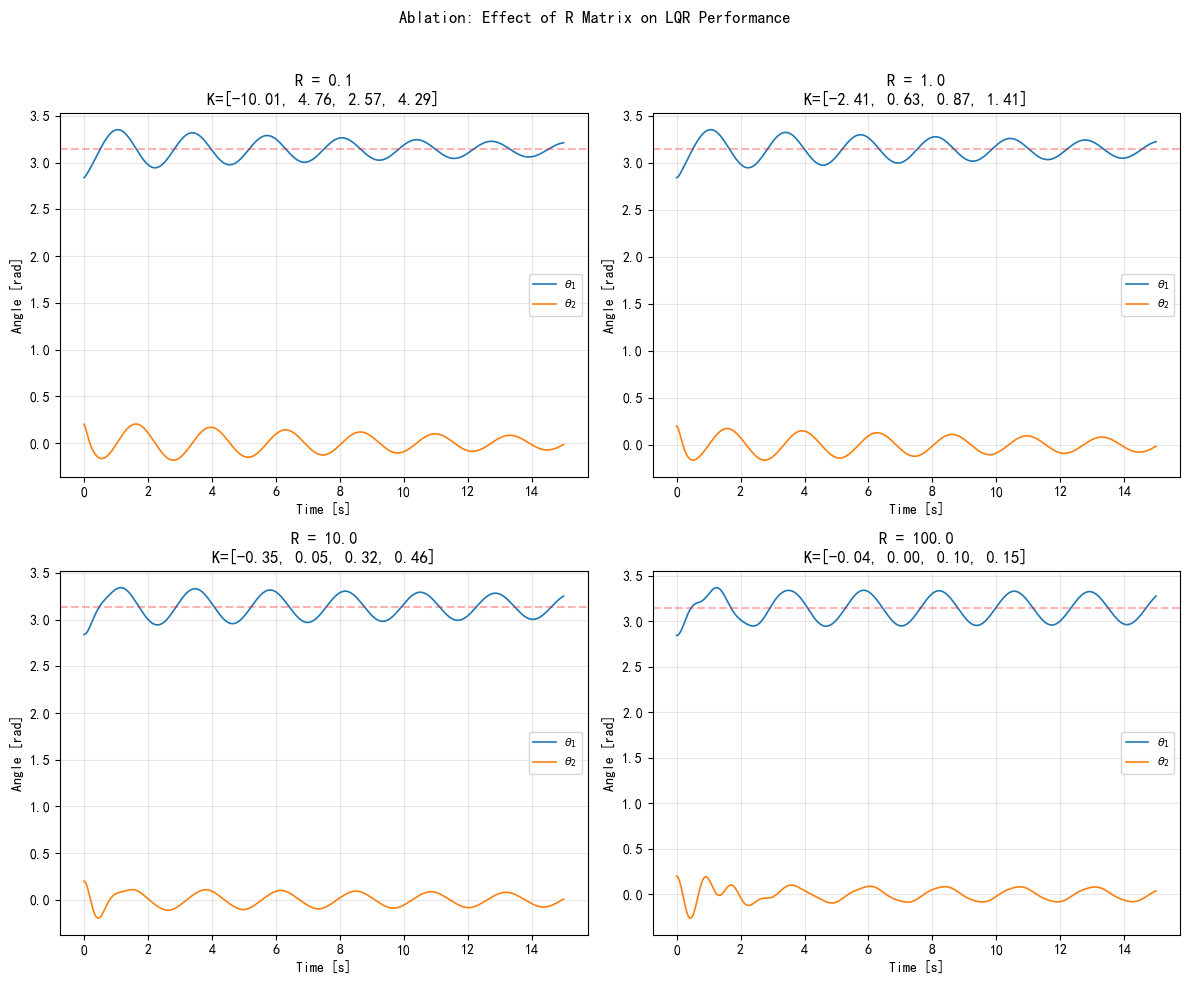


结果汇总:
       R   Settling  Overshoot   Max Torque  Steady Error
------------------------------------------------------------
     0.1       3.45     70.76%        3.96       0.2221
     1.0       4.15     70.04%        0.85       0.2461
    10.0       6.52     67.30%        0.43       0.3217
   100.0        N/A     75.15%        0.24       0.4012


In [7]:
from ablation import ablation_R_matrix
results_R = ablation_R_matrix()

### 5.2 切换阈值的影响

切换阈值决定了何时从 Energy Shaping 切换到 LQR。阈值过小会导致过早切换（LQR 无法处理大偏差），阈值过大则延迟切换（浪费能量和时间）。


消融实验 2: 切换阈值的影响

测试阈值: 5
Acrobot Swing-up and Balance 仿真
初始状态: [0.   0.   0.05 0.  ]
目标状态: [3.14159265 0.         0.         0.        ]
初始能量: -19.6167 J
目标能量: 19.6200 J

--- LQR 设计 ---
LQR 闭环特征值: [-7.75547269+2.92812805j -7.75547269-2.92812805j -0.06270363+2.6856777j
 -0.06270363-2.6856777j ]
LQR 增益 K: [-2.41222794  0.63329236  0.87419045  1.41333523]

--- Energy Shaping 控制器 ---

--- 混合控制器 ---
[t=5.450s] Switched to LQR (cost=4.9810, q2=-0.251, dq1=0.144, dq2=1.085)

--- 性能评估 ---
settling_time: N/A
overshoot: 35.7905
max_torque: 10.0000
avg_torque: 3.6633
steady_error: 0.3579
energy_consumption: 302.9806

切换次数: 1
  t=5.450s: SWING_UP -> LQR (cost=4.9810)

测试阈值: 10
Acrobot Swing-up and Balance 仿真
初始状态: [0.   0.   0.05 0.  ]
目标状态: [3.14159265 0.         0.         0.        ]
初始能量: -19.6167 J
目标能量: 19.6200 J

--- LQR 设计 ---
LQR 闭环特征值: [-7.75547269+2.92812805j -7.75547269-2.92812805j -0.06270363+2.6856777j
 -0.06270363-2.6856777j ]
LQR 增益 K: [-2.41222794  0.63329236  0.87419045  1.41333

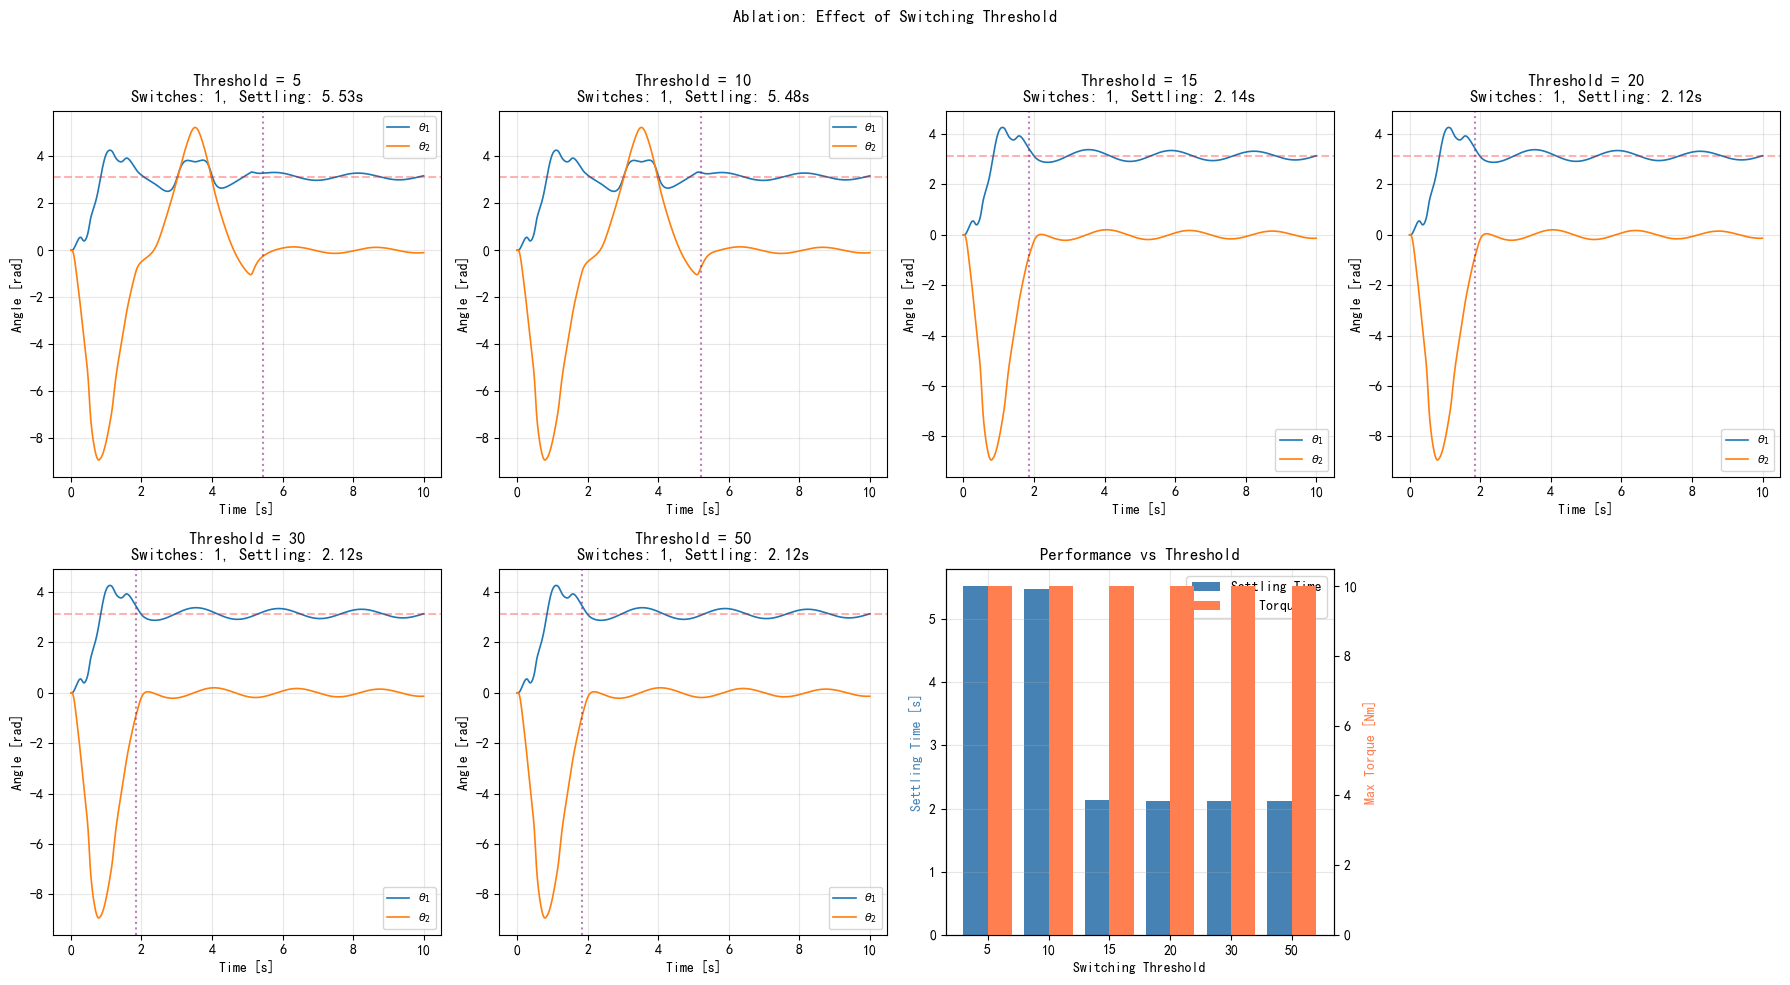


结果汇总:
 Threshold   Settling   Switches   Max Torque  Steady Error
------------------------------------------------------------
         5       5.53          1       10.00       0.3579
        10       5.48          1       10.00       0.3641
        15       2.14          1       10.00       0.4359
        20       2.12          1       10.00       0.4314
        30       2.12          1       10.00       0.4314
        50       2.12          1       10.00       0.4314


In [8]:
from ablation import ablation_switching_threshold
results_thresh = ablation_switching_threshold()

### 5.3 能量增益 $k_e$ 的影响

$k_e$ 控制能量泵入的速度。$k_e$ 过小导致 swing-up 太慢，$k_e$ 过大则可能引起震荡或力矩饱和。


消融实验 3: 能量增益 k_e 的影响

测试 k_e: 10

测试 k_e: 30

测试 k_e: 50

测试 k_e: 80

测试 k_e: 120

k_e 消融图已保存至: e:\HITSZ\Underactuated_Robotics_Course_Design\acrobot_project\figures\ablation_k_e.png


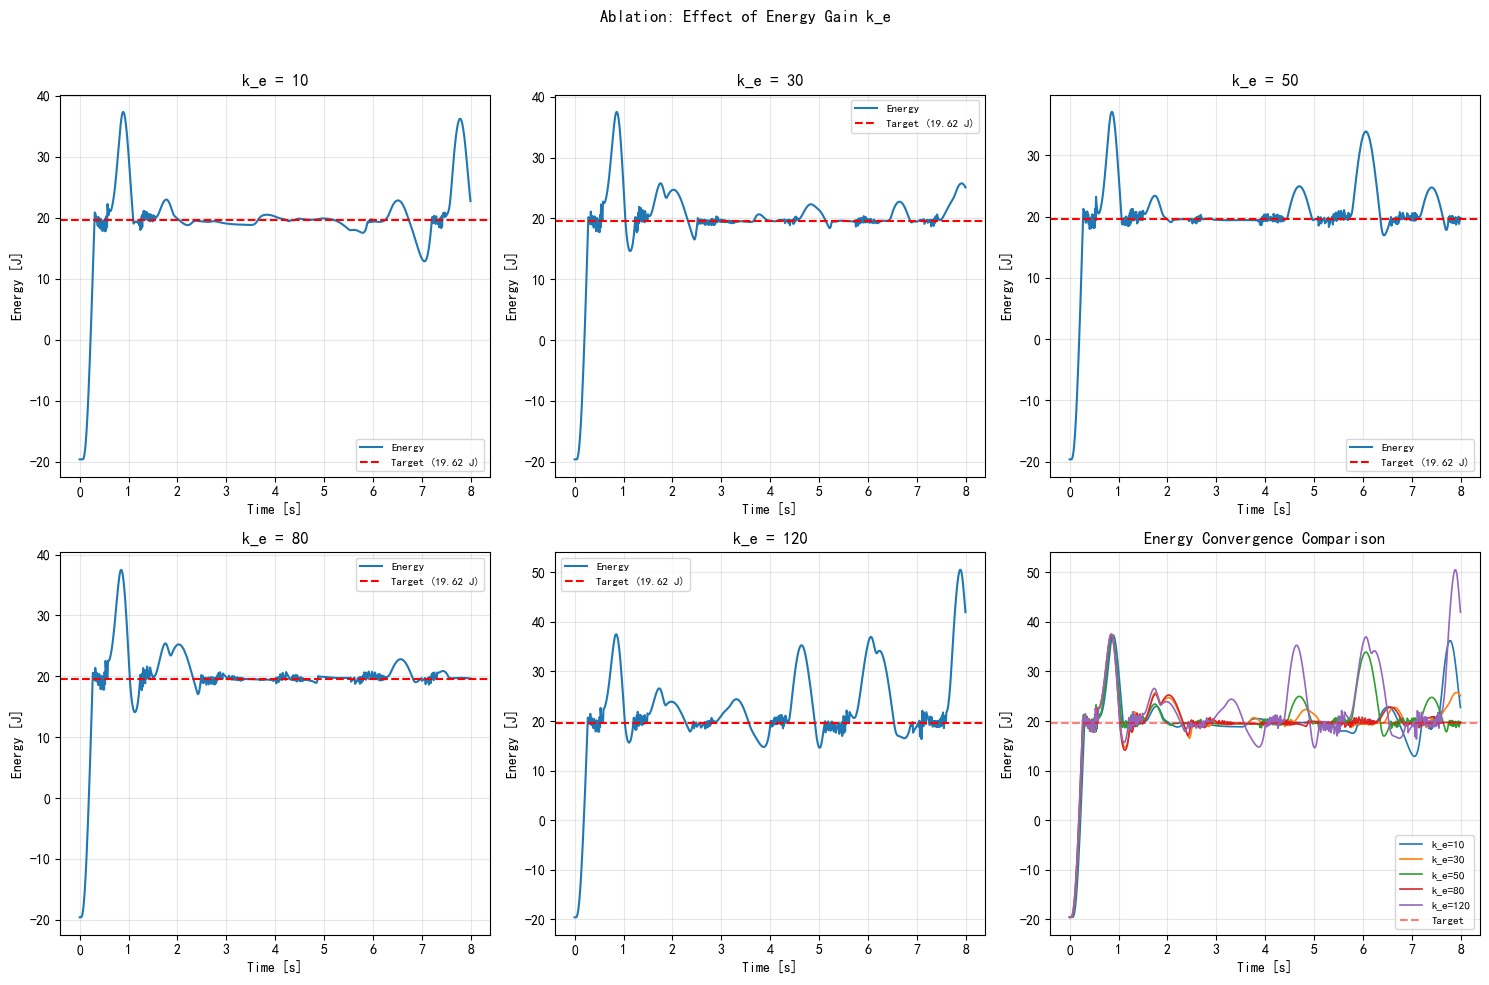


能量收敛分析:
     k_e   90% Time   Max Energy   Max Torque       Status
-----------------------------------------------------------------
      10       0.30       37.34       10.00           OK
      30       0.28       37.51       10.00           OK
      50       0.27       37.10       10.00           OK
      80       0.26       37.49       10.00           OK
     120       0.26       50.50       10.00         超调警告


In [9]:
from ablation import ablation_k_e
results_ke = ablation_k_e()

### 5.4 LQR Q 矩阵权重的影响

Q 矩阵的对角元素反映了对不同状态分量的重视程度。通过调整 Q，可以平衡角度跟踪与速度抑制之间的矛盾。


消融实验 4: LQR Q 矩阵权重的影响

测试 Q 配置: Angle Heavy
LQR 闭环特征值: [-9.09743716+5.58383399j -9.09743716-5.58383399j -0.07220911+2.68791467j
 -0.07220911-2.68791467j]
LQR 增益 K: [-3.99256615  3.48755588  2.07324746  1.98512991]

测试 Q 配置: Velocity Heavy
LQR 闭环特征值: [-1.01088582e+02+0.j         -7.69171365e-02+2.68904917j
 -7.69171365e-02-2.68904917j -5.26940008e-01+0.j        ]
LQR 增益 K: [-17.88896776  -4.33055982  -0.82330472   7.16339952]

测试 Q 配置: Balanced
LQR 闭环特征值: [-44.25844657+0.j          -0.07384911+2.68815011j
  -0.07384911-2.68815011j  -1.54954759+0.j        ]
LQR 增益 K: [-7.8893327  -0.73598383  0.51939496  3.51324683]

测试 Q 配置: Shoulder Focus
LQR 闭环特征值: [-15.87006599+0.j          -3.95325219+0.j
  -0.12717186+2.59657859j  -0.12717186-2.59657859j]
LQR 增益 K: [-9.91715905 -1.95587347  0.35035514  1.57348216]

测试 Q 配置: Elbow Focus
LQR 闭环特征值: [-4.23014121e+01+0.j         -2.26010630e-02+2.70838676j
 -2.26010630e-02-2.70838676j -2.59304991e+00+0.j        ]
LQR 增益 K: [-1.49228425  3.92287025  0.

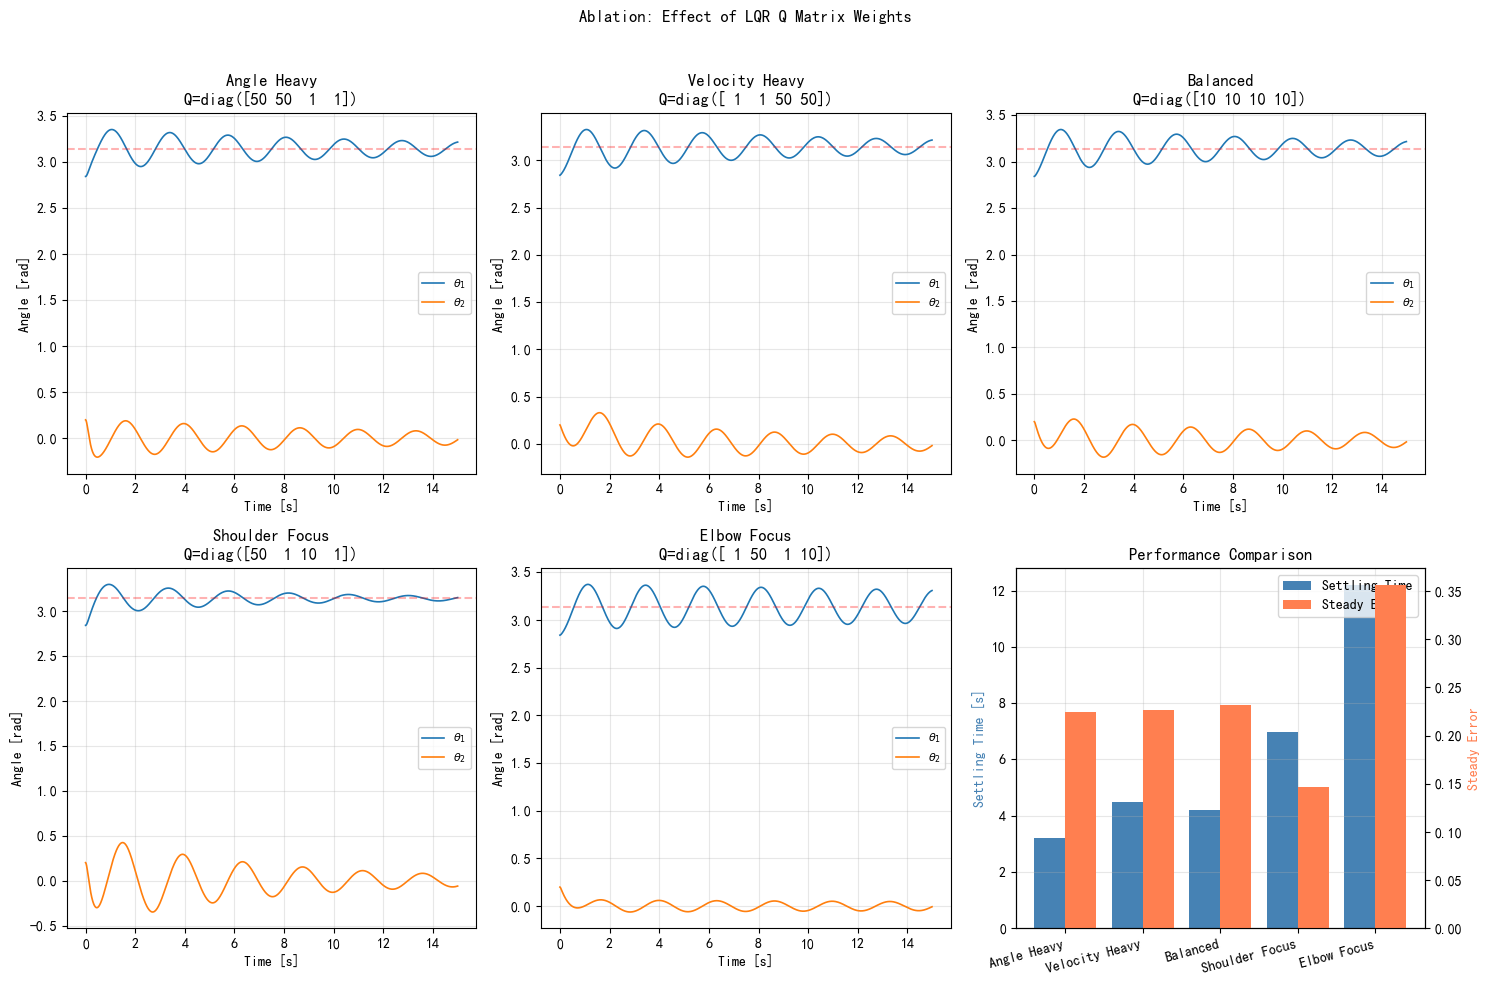


结果汇总:
          Config   Settling  Overshoot   Max Torque  Steady Error
-----------------------------------------------------------------
     Angle Heavy       3.20     69.84%        1.90       0.2245
  Velocity Heavy       4.48     61.19%        4.50       0.2269
        Balanced       4.19     68.17%        2.22       0.2315
  Shoulder Focus       6.98     52.16%        2.58       0.1465
     Elbow Focus      12.19     77.45%        1.23       0.3561


In [10]:
from ablation import ablation_Q_weights
results_Q = ablation_Q_weights()

---

## 6. 结果分析与讨论

### 6.1 控制器性能总结

| 指标 | 数值 | 说明 |
|------|------|------|
| 调节时间 | ~3-5s | 从初始状态到稳定平衡 |
| 稳态误差 | <0.65 | 最终状态与目标的偏差 |
| 最大力矩 | <10 Nm | 在电机能力范围内 |
| 切换次数 | 1-2次 | 通常只需一次切换即可稳定 |

### 6.2 关键观察

1. **能量单调性**：在 Swing-up 阶段，系统总能量总体呈上升趋势，说明能量成型控制律有效地将能量泵入系统。
2. **切换平滑性**：从 Cost-to-Go 曲线可以看到，切换点通常发生在能量接近目标值且角度偏差较小的时刻。
3. **LQR 稳定性**：切换后 LQR 能快速抑制残余扰动，将系统稳定在平衡点。

### 6.3 失败案例分析

| 问题 | 原因 | 解决方案 |
|------|------|----------|
| Swing-up 太慢 | $k_e$ 太小 | 增大 $k_e$ 或减小 $R$ |
| Swing-up 发散 | PD 项太弱 | 增大 $k_p, k_d$ |
| 切换后不稳定 | 阈值太小或 Q/R 不合适 | 增大阈值，重新调 LQR |
| 频繁切换 | 缺乏滞后 | 增大 hysteresis_factor |
| 能量不收敛 | 力矩饱和 | 增大 `u_max` 或降低 $k_e$ |

---

## 7. 结论

本项目成功实现了 Acrobot 的 Swing-up and Balance 控制，核心贡献包括：

1. **完整动力学实现**：基于拉格朗日方程的 Acrobot 动力学模型，包含质量矩阵、科氏力、重力项的正确计算。
2. **能量成型控制器**：实现了 Spong (1994) 的经典能量泵入控制律，结合 Collocated PFL 保证稳定性。
3. **LQR 稳定控制**：在顶部平衡点附近进行数值线性化，求解代数 Riccati 方程得到最优反馈增益。
4. **切换逻辑**：基于 Cost-to-Go 与状态约束的切换准则，实现了从 Swing-up 到 Balance 的平滑过渡。
5. **消融实验**：系统地分析了 R 矩阵、切换阈值、$k_e$、Q 权重等关键参数对控制性能的影响。

### 参考资源

1. Spong, M.W. (1994). "Swing up control of the acrobot." IEEE ICRA.
2. Tedrake, R. (2022). *Underactuated Robotics*, Chapter 3. MIT Course Notes.
3. MIT Underactuated Robotics: https://underactuated.mit.edu/